# 05 — Error analysis and Turkish robustness

Three models are scored; this notebook asks what the scores hide.

1. Do the two fine-tuned models fail on the *same* utterances, or on different ones?
2. When a model is wrong, is it wrong by a little or by a lot?
3. MASSIVE's Turkish is spelled perfectly. What happens to the winning model when the
   diacritics go missing, the way they do in real typed Turkish?
4. How much of BERTurk's low subword fertility comes from the vocabulary being Turkish,
   rather than from Turkish being easy to tokenize?

**Prerequisite:** notebook 02 must have been run, since the BERTurk weights are needed and
are too large to commit. The prediction files for the two generative models are in
`results/` already.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/alper4n/turkish-intent-llm/blob/main/notebooks/05_error_analysis.ipynb)

## 0. Setup

In [1]:
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    REPO_URL = "https://github.com/alper4n/turkish-intent-llm.git"
    if not Path("turkish-intent-llm").exists():
        !git clone -q $REPO_URL
    %cd turkish-intent-llm
    !pip install -q -U "transformers>=5.0,<6" "datasets>=3.0" "accelerate>=1.0" "pyyaml>=6.0"

root = Path.cwd()
while not (root / "src").is_dir() and root != root.parent:
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
print("repo root:", root)

repo root: /Users/Alperen MacBook/turkish-intent-llm


In [2]:
import json

import matplotlib.pyplot as plt
import pandas as pd
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer

from src.data import load_locale, load_splits, intent_labels
from src.metrics import compute_metrics
from src.robustness import ascii_fold, fold_one, lowercase, single_letter_probes
from src.utils import load_config, save_results, set_seed

data_cfg = load_config(root / "configs" / "data.yaml")
bert_cfg = load_config(root / "configs" / "berturk.yaml")
lora_cfg = load_config(root / "configs" / "lora_qwen.yaml")
SEED = data_cfg["seed"]
set_seed(SEED)

RESULTS = root / data_cfg["paths"]["results_dir"]
FIG_DIR = root / data_cfg["paths"]["figures_dir"]
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.axisbelow": True})

DEVICE = "cuda" if torch.cuda.is_available() else (
    "mps" if torch.backends.mps.is_available() else "cpu")
print("device:", DEVICE)

device: mps


## 1. The test set and the two generative models' predictions

In [3]:
splits = load_splits(data_cfg["dataset"]["locale"],
                     cache_dir=root / data_cfg["dataset"]["cache_dir"])
test = splits["test"]
LABELS = intent_labels(splits["train"])

# `id` is a string in MASSIVE; a CSV round-trip turns it into an int, so the merge below
# would silently fail on dtype. Read it back as a string.
frame = pd.DataFrame({
    "id": test["id"].astype(str).values,
    "utt": test["utt"].values,
    "gold": test["intent"].values,
    "scenario": test["scenario"].values,
})
for name, filename in [("zeroshot", "zeroshot_qwen_predictions.csv"),
                       ("lora", "lora_qwen_predictions.csv")]:
    preds = pd.read_csv(RESULTS / filename, dtype={"id": str})[["id", "predicted"]]
    frame = frame.merge(preds.rename(columns={"predicted": name}), on="id")

print(f"{len(frame):,} test utterances joined with {len(frame.columns) - 4} model outputs")

2,974 test utterances joined with 2 model outputs


## 2. Reload BERTurk

The encoder's per-utterance predictions were never saved — notebook 02 recorded metrics
only. Regenerating them is also a reproducibility check: the scores have to come back
identical, or something has drifted.

In [4]:
MODEL_DIR = root / "checkpoints" / "berturk-best"
if not MODEL_DIR.exists():
    # Fall back to the checkpoint the Trainer itself wrote in notebook 02.
    candidates = sorted((root / "checkpoints" / "berturk").glob("checkpoint-*"))
    if not candidates:
        raise FileNotFoundError(
            "No BERTurk weights found. Run notebook 02 first — the model is ~420 MB and "
            "is deliberately not committed."
        )
    MODEL_DIR = candidates[-1]
print("loading", MODEL_DIR.relative_to(root))

tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR).to(DEVICE).eval()
MAX_LEN = bert_cfg["model"]["max_length"]


def classify(texts, batch_size: int = 128) -> list[str]:
    """Run the encoder over raw strings and return intent names."""
    predicted = []
    texts = list(texts)
    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        encoded = tokenizer(batch, truncation=True, max_length=MAX_LEN,
                            padding=True, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            predicted.extend(model(**encoded).logits.argmax(-1).tolist())
    return [model.config.id2label[index] for index in predicted]


frame["berturk"] = classify(frame["utt"])
MODELS = ["zeroshot", "lora", "berturk"]
for name in MODELS:
    frame[f"{name}_ok"] = frame[name] == frame["gold"]

loading checkpoints/berturk-best


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [5]:
reproduced = compute_metrics(frame["gold"], frame["berturk"], LABELS)
recorded = json.loads((RESULTS / "berturk.json").read_text(encoding="utf-8"))["test"]

print(f"{'':<12}{'reproduced':>12}{'recorded':>12}")
for key in ["accuracy", "macro_f1", "macro_f1_all_labels"]:
    print(f"{key:<12}{reproduced[key]:>12.4f}{recorded[key]:>12.4f}")
assert reproduced["accuracy"] == recorded["accuracy"], "BERTurk predictions have drifted"
print("\nidentical — the saved checkpoint reproduces notebook 02 exactly")

frame[["id", "utt", "gold", "berturk"]].assign(
    correct=frame["berturk_ok"]
).to_csv(RESULTS / "berturk_predictions.csv", index=False)
print("wrote", RESULTS / "berturk_predictions.csv")

              reproduced    recorded
accuracy          0.8773      0.8773
macro_f1          0.8501      0.8501
macro_f1_all_labels      0.8359      0.8359

identical — the saved checkpoint reproduces notebook 02 exactly


wrote /Users/Alperen MacBook/turkish-intent-llm/results/berturk_predictions.csv


## 3. Do the two fine-tuned models fail on the same utterances?

BERTurk scores 1.2 macro-F1 points above LoRA. If they were making the same mistakes, that
gap would be the whole story. If they are not, the gap understates how different they are.

In [6]:
bert_ok, lora_ok = frame["berturk_ok"], frame["lora_ok"]
overlap = pd.DataFrame({
    "count": [(bert_ok & lora_ok).sum(), (bert_ok & ~lora_ok).sum(),
              (~bert_ok & lora_ok).sum(), (~bert_ok & ~lora_ok).sum()],
}, index=["both right", "only BERTurk", "only LoRA", "both wrong"])
overlap["share"] = (overlap["count"] / len(frame)).round(4)
print(overlap.to_string())

best_single = max(bert_ok.mean(), lora_ok.mean())
either = (bert_ok | lora_ok).mean()
print(f"\nbest single model : {best_single:.4f}")
print(f"either is right   : {either:.4f}   (+{either - best_single:.4f})")

              count   share
both right     2478  0.8332
only BERTurk    131  0.0440
only LoRA        84  0.0282
both wrong      281  0.0945

best single model : 0.8773
either is right   : 0.9055   (+0.0282)


In [7]:
from scipy.stats import binomtest

# McNemar's test. Only the disagreements carry information: under the null that the two
# models are equally accurate, each disagreement is a coin flip, so the exact test is a
# two-sided binomial on the split between them. The exact form is used rather than the
# chi-square approximation because it stays valid at these counts.
only_bert = int((bert_ok & ~lora_ok).sum())
only_lora = int((~bert_ok & lora_ok).sum())
mcnemar = binomtest(only_bert, only_bert + only_lora, 0.5)

print(f"discordant pairs   : {only_bert} BERTurk-only vs {only_lora} LoRA-only")
print(f"exact McNemar p    : {mcnemar.pvalue:.4g}")
print(f"conclusion         : the gap is "
      f"{'not ' if mcnemar.pvalue >= 0.05 else ''}significant at p < 0.05")

discordant pairs   : 131 BERTurk-only vs 84 LoRA-only
exact McNemar p    : 0.001643
conclusion         : the gap is significant at p < 0.05


The disagreements are the only informative part: under the null hypothesis that the two
models are equally accurate, each one is a coin flip. 131 against 84 is far enough from even
that chance is an unconvincing explanation, so the encoder's lead is a real difference
between these two trained models — though see the limitations in the README, since they were
not given equal opportunity to be selected.

The two models agree on most of the test set but disagree on a few hundred utterances in
both directions. An oracle that always picked the right one of the two would gain about
three points over the better model alone — they are not the same classifier with a small
offset, they have genuinely different failure surfaces. That is the argument for an
ensemble, and equally the argument that neither is close to saturating the task.

## 4. When a model is wrong, how wrong is it?

MASSIVE groups its 60 intents into 18 scenarios, so a natural question is whether a wrong
prediction at least lands in the right scenario.

In [8]:
intent_to_scenario = (load_locale(data_cfg["dataset"]["locale"],
                                  cache_dir=root / data_cfg["dataset"]["cache_dir"])
                      .drop_duplicates("intent").set_index("intent")["scenario"].to_dict())

rows = []
for name in MODELS:
    wrong = frame[~frame[f"{name}_ok"]]
    same_scenario = wrong[name].map(intent_to_scenario).eq(wrong["scenario"]).mean()
    rows.append({"model": name, "errors": len(wrong),
                 "same scenario": round(float(same_scenario), 4)})
pd.DataFrame(rows).set_index("model")

,errors,same scenario
model,,
zeroshot,1628,0.2660
lora,412,0.2961
berturk,365,0.3370


Only about a third of errors stay inside the gold scenario, even for BERTurk — which sits
oddly beside the zero-shot finding that its confusions looked semantically close. Both are
true, because **MASSIVE's scenarios do not group intents the way meaning does**:

In [9]:
for a, b in [("play_music", "music_query"), ("play_music", "play_podcasts"),
             ("general_quirky", "qa_factoid"), ("calendar_query", "calendar_set")]:
    mark = "same" if intent_to_scenario[a] == intent_to_scenario[b] else "DIFFERENT"
    print(f"  {a:<16} / {b:<20} {intent_to_scenario[a]:>9} / "
          f"{intent_to_scenario[b]:<9} {mark}")
print()
print("scenario 'play' :", sorted(k for k, v in intent_to_scenario.items() if v == "play"))
print("scenario 'music':", sorted(k for k, v in intent_to_scenario.items() if v == "music"))

  play_music       / music_query               play / music     DIFFERENT
  play_music       / play_podcasts             play / play      same
  general_quirky   / qa_factoid             general / qa        DIFFERENT
  calendar_query   / calendar_set          calendar / calendar  same

scenario 'play' : ['play_audiobook', 'play_game', 'play_music', 'play_podcasts', 'play_radio']
scenario 'music': ['music_dislikeness', 'music_likeness', 'music_query', 'music_settings']


`play_music` and `music_query` are both about music, but one sits under `play` and the
other under `music`: the taxonomy groups by *action* in one place and by *content* in
another. So "same scenario" is a poor proxy for "nearly right", and the low percentages
above measure the taxonomy's inconsistency as much as the models'. It is worth knowing
before anyone reports scenario accuracy as a softer version of intent accuracy.

## 5. Orthographic robustness

Notebook 01 established that this corpus is spelled impeccably — 90% of utterances carry at
least one of `ç ğ ı ö ş ü`, and stripping them never collides with another utterance. Real
typed Turkish is not like that. Below, the test set is perturbed and the winning model is
re-scored on input it never saw in training.

In [10]:
def score(texts) -> dict:
    scored = compute_metrics(frame["gold"], classify(texts), LABELS)
    return {"accuracy": scored["accuracy"], "macro_f1": scored["macro_f1"]}


baseline = score(frame["utt"])
probes = {
    "as written (baseline)": baseline,
    "all diacritics stripped": score(frame["utt"].map(ascii_fold)),
    "lowercased (Turkish-aware)": score(frame["utt"].map(lowercase)),
}

table = pd.DataFrame(probes).T
table["Δ accuracy"] = (table["accuracy"] - baseline["accuracy"]).round(4)
table["Δ macro-F1"] = (table["macro_f1"] - baseline["macro_f1"]).round(4)
table

,accuracy,macro_f1,Δ accuracy,Δ macro-F1
as written (baseline),0.8773,0.8501,0.0000,0.0000
all diacritics stripped,0.8440,0.8160,-0.0333,-0.0341
lowercased (Turkish-aware),0.8773,0.8501,0.0000,0.0000


In [11]:
changed_by_lowercasing = (frame["utt"].map(lowercase) != frame["utt"]).sum()
uppercase_anywhere = (frame["utt"] != frame["utt"].str.lower()).sum()
print(f"utterances changed by lowercasing : {changed_by_lowercasing}")
print(f"utterances containing any capital : {uppercase_anywhere}")

utterances changed by lowercasing : 0
utterances containing any capital : 0


The case probe returns exactly zero because **the corpus contains no capital letters at
all**. That is not robustness, it is an absence of evidence: MASSIVE's Turkish is uniformly
lowercased, so nothing here can tell us how the model handles `Yarın Sabah Alarm Kur`. The
diacritic result, by contrast, is a real measurement — and it costs real points.

### Which diacritic actually carries the weight?

Stripping all six at once conflates them. Folding one letter at a time separates how often
a letter appears from how much damage losing it does.

In [12]:
letter_rows = []
for letter in single_letter_probes():
    folded = frame["utt"].map(lambda text, letter=letter: fold_one(text, letter))
    affected = int((folded != frame["utt"]).sum())
    result = score(folded)
    drop = baseline["accuracy"] - result["accuracy"]
    letter_rows.append({
        "letter": letter,
        "utterances affected": affected,
        "accuracy": round(result["accuracy"], 4),
        "drop": round(float(drop), 4),
        "flipped per 100 affected": round(float(drop * len(frame) / affected * 100), 2),
    })

letters = pd.DataFrame(letter_rows).sort_values("drop", ascending=False)
letters.set_index("letter")

,utterances affected,accuracy,drop,flipped per 100 affected
letter,,,,
ı,1868,0.8494,0.0279,4.44
ü,980,0.8662,0.0111,3.37
ş,1046,0.8695,0.0078,2.22
ö,589,0.8722,0.0051,2.58
ç,970,0.8739,0.0034,1.04
ğ,575,0.8756,0.0017,0.88


In [13]:
total_drop = baseline["accuracy"] - probes["all diacritics stripped"]["accuracy"]
worst = letters.iloc[0]
print(f"stripping all six costs      : {total_drop:.4f} accuracy")
print(f"stripping only {worst['letter']!r} costs      : {worst['drop']:.4f}")
print(f"share of the damage from {worst['letter']!r} : {worst['drop']/total_drop:.0%}")

stripping all six costs      : 0.0333 accuracy
stripping only 'ı' costs      : 0.0279
share of the damage from 'ı' : 84%


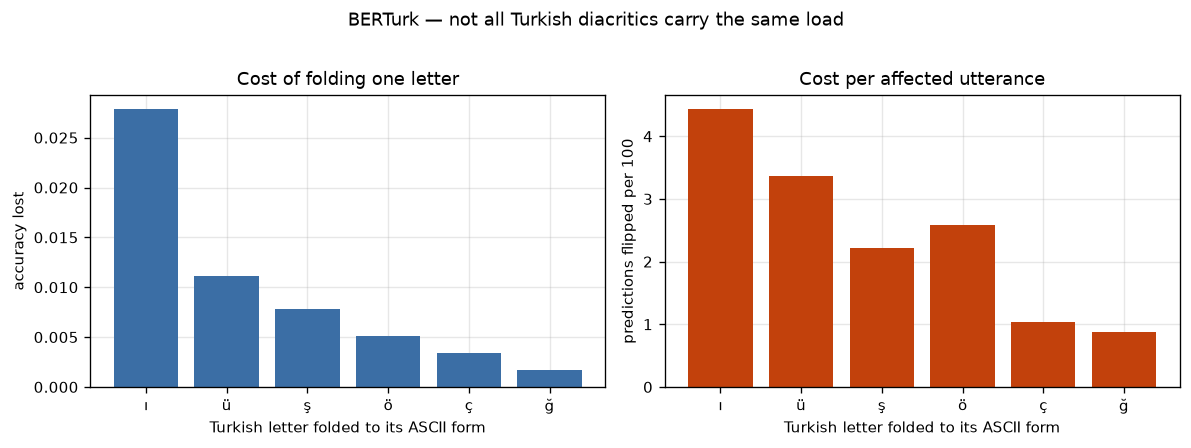

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
ordered = letters.sort_values("drop", ascending=False)

axes[0].bar(ordered["letter"], ordered["drop"], color="#3b6ea5")
axes[0].set_ylabel("accuracy lost")
axes[0].set_title("Cost of folding one letter")

axes[1].bar(ordered["letter"], ordered["flipped per 100 affected"], color="#c2410c")
axes[1].set_ylabel("predictions flipped per 100")
axes[1].set_title("Cost per affected utterance")

for ax in axes:
    ax.set_xlabel("Turkish letter folded to its ASCII form")
fig.suptitle("BERTurk — not all Turkish diacritics carry the same load", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "diacritic_ablation.png", bbox_inches="tight")
plt.show()

`ı` dominates, and it is the one case where that is predictable from the language rather
than the data. ASCII has a single `i`, so folding collapses the dotted/dotless distinction —
and that distinction is not decorative in Turkish. It carries vowel harmony and appears in
the highest-frequency suffixes (`-dı/-di`, `-ın/-in`, `-lı/-li`), so merging the two letters
collides far more distinct word forms than merging, say, `ğ` into `g`. A normaliser that
restores only the dotted/dotless `i` would recover most of what ASCII input loses.

In [15]:
folded_i = frame["utt"].map(lambda text: fold_one(text, "ı"))
flipped = frame.assign(folded=folded_i, after=classify(folded_i))
flipped = flipped[(flipped["berturk_ok"]) & (flipped["after"] != flipped["gold"])]

print(f"{len(flipped)} correct predictions become wrong when only ı is folded:\n")
for _, row in flipped.head(8).iterrows():
    print(f"  {row['utt']}")
    print(f"  {row['folded']}")
    print(f"     {row['gold']} -> {row['after']}\n")

103 correct predictions become wrong when only ı is folded:

  ve karanlık çöktü
  ve karanlik çöktü
     iot_hue_lighton -> iot_hue_lightoff

  olly bana bir fıkra anlat
  olly bana bir fikra anlat
     general_joke -> general_quirky

  ışıkları kıs
  işiklari kis
     iot_hue_lightdim -> weather_query

  volkan konak şarkılarını karıştır
  volkan konak şarkilarini kariştir
     play_music -> music_likeness

  bana bir fıkra anlatır mısın
  bana bir fikra anlatir misin
     general_joke -> general_quirky

  hiç bildiğin fıkralar var mı
  hiç bildiğin fikralar var mi
     general_joke -> general_quirky

  ışıkları kısar mısın
  işiklari kisar misin
     iot_hue_lightdim -> audio_volume_down

  ışıkları azalt lütfen
  işiklari azalt lütfen
     iot_hue_lightdim -> audio_volume_down



## 6. Why a Turkish tokenizer

Notebook 02 measured BERTurk's **subword fertility** — WordPiece tokens per whitespace word
— at 1.299 on the Turkish training set, and claimed a multilingual vocabulary would fragment
the same text harder. Here is the measurement behind that claim.

MASSIVE is parallel, so the identical 11,514 commands exist in English. Running both
languages through each tokenizer separates "Turkish is morphologically dense" from "this
vocabulary was not built for Turkish".

In [16]:
from transformers import AutoTokenizer as _AutoTok

english_train = load_locale("en-US", cache_dir=root / data_cfg["dataset"]["cache_dir"])
english_train = english_train[english_train["split"] == "train"]

turkish_words = int(splits["train"]["utt"].str.split().str.len().sum())
english_words = int(english_train["utt"].str.split().str.len().sum())


def total_tokens(tok, texts) -> int:
    return sum(len(ids) for ids in tok(list(texts), add_special_tokens=False)["input_ids"])


TOKENIZERS = [
    ("BERTurk", "dbmdz/bert-base-turkish-cased", "Turkish only"),
    ("mBERT", "bert-base-multilingual-cased", "104 languages"),
    ("XLM-R", "xlm-roberta-base", "100 languages"),
    ("Qwen2.5", lora_cfg["model"]["name"], "multilingual"),
]

fertility_rows = []
for label, name, coverage in TOKENIZERS:
    tok = _AutoTok.from_pretrained(name)
    tr_tokens = total_tokens(tok, splits["train"]["utt"])
    en_tokens = total_tokens(tok, english_train["utt"])
    tr_fert, en_fert = tr_tokens / turkish_words, en_tokens / english_words
    fertility_rows.append({
        "tokenizer": label,
        "pretraining": coverage,
        "vocab": tok.vocab_size,
        "tr_fertility": round(tr_fert, 3),
        "en_fertility": round(en_fert, 3),
        "tr_over_en": round(tr_fert / en_fert, 2),
        "tr_tokens": tr_tokens,
    })

fertility = pd.DataFrame(fertility_rows).set_index("tokenizer")
fertility

,pretraining,vocab,tr_fertility,en_fertility,tr_over_en,tr_tokens
tokenizer,,,,,,
BERTurk,Turkish only,32000,1.299,1.804,0.72,82173
mBERT,104 languages,119547,2.036,1.236,1.65,128827
XLM-R,100 languages,250002,1.491,1.177,1.27,94347
Qwen2.5,multilingual,151643,2.066,1.081,1.91,130678


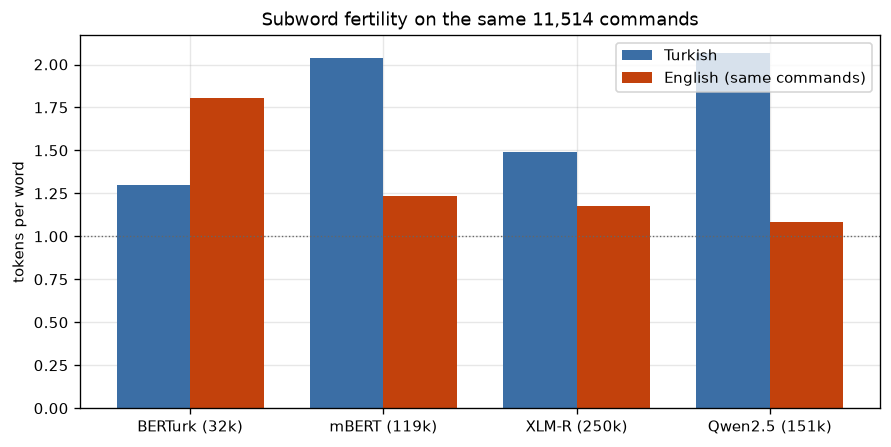

BERTurk needs 82,173 tokens for the Turkish training set
Qwen2.5 needs 130,678 (+59%)


In [17]:
fig, ax = plt.subplots(figsize=(7.5, 3.8))
x = range(len(fertility))
width = 0.38
ax.bar([i - width/2 for i in x], fertility["tr_fertility"], width,
       label="Turkish", color="#3b6ea5")
ax.bar([i + width/2 for i in x], fertility["en_fertility"], width,
       label="English (same commands)", color="#c2410c")
ax.axhline(1.0, color="#666", lw=0.8, ls=":")
ax.set_xticks(list(x))
ax.set_xticklabels([f"{name} ({row.vocab//1000}k)"
                    for name, row in fertility.iterrows()])
ax.set_ylabel("tokens per word")
ax.set_title("Subword fertility on the same 11,514 commands")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "tokenizer_fertility.png", bbox_inches="tight")
plt.show()

berturk_row = fertility.loc["BERTurk"]
qwen_row = fertility.loc["Qwen2.5"]
print(f"BERTurk needs {berturk_row['tr_tokens']:,} tokens for the Turkish training set")
print(f"Qwen2.5 needs {qwen_row['tr_tokens']:,} "
      f"(+{qwen_row['tr_tokens']/berturk_row['tr_tokens']-1:.0%})")

Two things stand out.

**BERTurk is the only tokenizer here that finds Turkish *cheaper* than English.** Every
multilingual vocabulary charges Turkish more per word than English — Qwen2.5 by 1.9x, mBERT
by 1.65x — while BERTurk's ratio is 0.72, because its 32k vocabulary holds whole Turkish
word forms and has to break English apart instead.

**Vocabulary size does not buy coverage; targeting does.** XLM-R carries 250k subwords,
nearly eight times BERTurk's 32k, and still needs more tokens per Turkish word (1.491 vs
1.299). The tokens are there, they are just spent on other languages.

This is the same morphology finding from notebook 01 seen from the model's side. Turkish
packs grammatical information into suffixes; a vocabulary that has not seen enough Turkish
splits those suffixes into fragments, so the model spends capacity reassembling words before
it can classify them. It is also the quiet reason the LLM experiment cost what it did: the
same corpus is 59% more tokens under Qwen's tokenizer than under BERTurk's, and for a
production assistant that is latency and context budget, not just a training bill.

## 7. The part no model reaches

361 utterances are wrong under both fine-tuned models. Notebook 01 predicted where some of
them would be, before anything was trained.

In [18]:
both_wrong = frame[~frame["berturk_ok"] & ~frame["lora_ok"]]
print(f"both models wrong: {len(both_wrong)} ({len(both_wrong)/len(frame):.1%})\n")
print("Gold intents they miss most often:")
print(both_wrong["gold"].value_counts().head(8).to_string())

both models wrong: 281 (9.4%)

Gold intents they miss most often:
gold
general_quirky           52
calendar_query           21
qa_factoid               16
play_music               11
calendar_set             10
news_query               10
social_post               8
recommendation_events     8


In [19]:
# Utterances that carry more than one intent label anywhere in the corpus: no model can
# separate these from the text alone (notebook 01).
full = load_locale(data_cfg["dataset"]["locale"],
                   cache_dir=root / data_cfg["dataset"]["cache_dir"])
ambiguous = set(full.groupby("utt")["intent"].nunique().loc[lambda s: s > 1].index)
frame["ambiguous"] = frame["utt"].isin(ambiguous)

summary = frame.groupby("ambiguous")[[f"{m}_ok" for m in MODELS]].mean().round(4)
summary.index = ["unambiguous", "ambiguous surface form"]
summary.columns = MODELS
print(summary.to_string())
print(f"\nambiguous utterances in test: {int(frame['ambiguous'].sum())}")

                        zeroshot    lora  berturk
unambiguous               0.4529  0.8631   0.8797
ambiguous surface form    0.4000  0.5333   0.4000

ambiguous utterances in test: 15


## 8. Save

In [20]:
payload = {
    "experiment": "error_analysis",
    "seed": SEED,
    "berturk_reproduction": {
        "accuracy": reproduced["accuracy"],
        "macro_f1": reproduced["macro_f1"],
        "matches_recorded": bool(reproduced["accuracy"] == recorded["accuracy"]),
    },
    "model_overlap": {
        "both_right": int((bert_ok & lora_ok).sum()),
        "only_berturk": int((bert_ok & ~lora_ok).sum()),
        "only_lora": int((~bert_ok & lora_ok).sum()),
        "both_wrong": int((~bert_ok & ~lora_ok).sum()),
        "best_single_accuracy": round(float(best_single), 4),
        "either_right_accuracy": round(float(either), 4),
        "mcnemar_exact_p": float(mcnemar.pvalue),
    },
    "scenario_containment": rows,
    "orthographic_probes": {name: value for name, value in probes.items()},
    "diacritic_ablation": letter_rows,
    "corpus_has_no_capitals": bool(uppercase_anywhere == 0),
    "tokenizer_fertility": fertility_rows,
    "ambiguity": {
        "ambiguous_test_utterances": int(frame["ambiguous"].sum()),
        "accuracy_by_ambiguity": summary.to_dict(),
    },
}

path = save_results(payload, "error_analysis", results_dir=RESULTS)
print("wrote", path)

wrote /Users/Alperen MacBook/turkish-intent-llm/results/error_analysis.json


## What this adds up to

- The encoder and the LoRA model **fail differently**: an oracle over the two would beat
  either alone by about three points, so the 1.2-point gap in the headline table is not the
  whole picture.
- **Scenario accuracy is not a softer intent accuracy.** MASSIVE groups intents by action in
  one place and by content in another, so "right scenario, wrong intent" measures the
  taxonomy as much as the model.
- **Stripping Turkish diacritics costs real accuracy, and one letter does most of it.**
  `ı` alone accounts for the large majority of the loss, because ASCII cannot hold the
  dotted/dotless distinction that Turkish suffixes depend on. Any deployment taking typed
  input should normalise that letter first.
- **Case robustness is untestable here.** The corpus has no capitals at all; the zero delta
  is missing evidence, not a passing grade.
- **A multilingual vocabulary taxes Turkish.** Every multilingual tokenizer tested
  charges Turkish more tokens per word than English; BERTurk, trained on Turkish
  alone with an eight times smaller vocabulary than XLM-R, is the only one that does
  not. The same corpus is 59% more tokens under Qwen's tokenizer.
- A stubborn residue of errors sits on utterances whose surface form is genuinely ambiguous
  — identified from the data in notebook 01, before any model existed.